In [20]:
from pathlib import Path
from matplotlib import pyplot as plt
import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

from imagematerials.buildings.preprocessing.floorspace import get_image_floorspace, get_floorspace_urban_rural
from imagematerials.buildings.preprocessing.population import compute_population

In [21]:
scenario_list = {"base":("SSP2",["base"]),
                 "narrow":("SSP2_narrow", ["base", "narrow"]),
                 "slow":("SSP2_slow",["base", "slow"]),
                 "close":("SSP2",["base", "close"]),
                 "narrow_slow_close":("SSP2_narrow_slow_close", ["base", "narrow","slow", "close"])
                 }

In [22]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1921
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1970, 2100, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dirs = {
        scenario: scenario_base_path / scenario for scenario in circular_scen
    }

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs) 
    vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # TODO fix this for real in the future
    prep_data = vhc_sector.prep_data

    target_materials = [
    "Aluminium", "Brick", "Cement", "Concrete", 
    "Copper", "Glass", "Steel", "Wood"
    ]

    prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
    prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

    vhc_sector = Sector('vehicles', prep_data)

    prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
    eol_sector = Sector(name="eol", data = prep_eol)

    factory = ModelFactory(
    [bld_sector, vhc_sector, eol_sector], complete_timeline
    ).add(GenericStocks, ["buildings", "vehicles"]
    ).add(GenericMaterials,  "vehicles"
    ).add(Maintenance, "vehicles"
    ).add(MaterialIntensities, "buildings",
    ).add(EndOfLife, "eol", input_sources={
    "outflow_by_cohort_materials": ["buildings", "vehicles"],
    "collection": "eol",
    "reuse": "eol",
    "recycling": "eol"}
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

        # simple output to be used in TIMER (for inflows, reusable and recyclable steel and concrete only)
    all_output[scen_id] = {
        "outflow_by_cohort_materials": [model.vehicles["outflow_by_cohort_materials"], model.buildings["outflow_by_cohort_materials"]],
        "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
        "stocks": [model.vehicles["stocks"], model.buildings["stocks"]],
        "stock_by_cohort_materials": [model.vehicles["stock_by_cohort_materials"], model.buildings["stock_by_cohort_materials"]],
        "sum_outflow": model.eol["sum_outflow"],
        "reusable_materials": model.eol["reusable_materials"],
        "recyclable_materials": model.eol["recyclable_materials"]
    }
    print(f"Finished {scen_id}")

    
    # full output to be reported (all materials, all variables) 
    #TODO: add all variables to the output

    # all_output[scen_id] = {
        # "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
        # "stocks": [model.vehicles["stocks"], model.buildings["stocks"]],
    #     "outflow_by_cohort_materials": [model.vehicles["outflow_by_cohort_materials"], model.buildings["outflow_by_cohort_materials"]],
    #    
    #     "reusable_materials": model.eol["reusable_materials"], 
    #     "recyclable_materials": model.eol["recyclable_materials"]
    # }
    # print(f"Finished {scen_id}")

implemented 'base' for Residential Buildings
Finished base
implemented 'base' for Residential Buildings
implemented 'narrow' for Residential Buildings
implemented 'narrow' for Vehicles
Finished narrow
implemented 'base' for Residential Buildings
implemented 'slow' for Buildings
implemented 'slow' for Vehicles
implemented 'slow' for buildings eol
implemented 'slow' for vehicles eol
Finished slow
implemented 'base' for Residential Buildings
implemented 'close' for buildings eol
implemented 'close' for vehicles eol
Finished close
implemented 'base' for Residential Buildings
implemented 'narrow' for Residential Buildings
implemented 'slow' for Buildings
implemented 'slow' for Vehicles
implemented 'narrow' for Vehicles
implemented 'slow' for buildings eol
implemented 'slow' for vehicles eol
implemented 'close' for buildings eol
implemented 'close' for vehicles eol
Finished narrow_slow_close


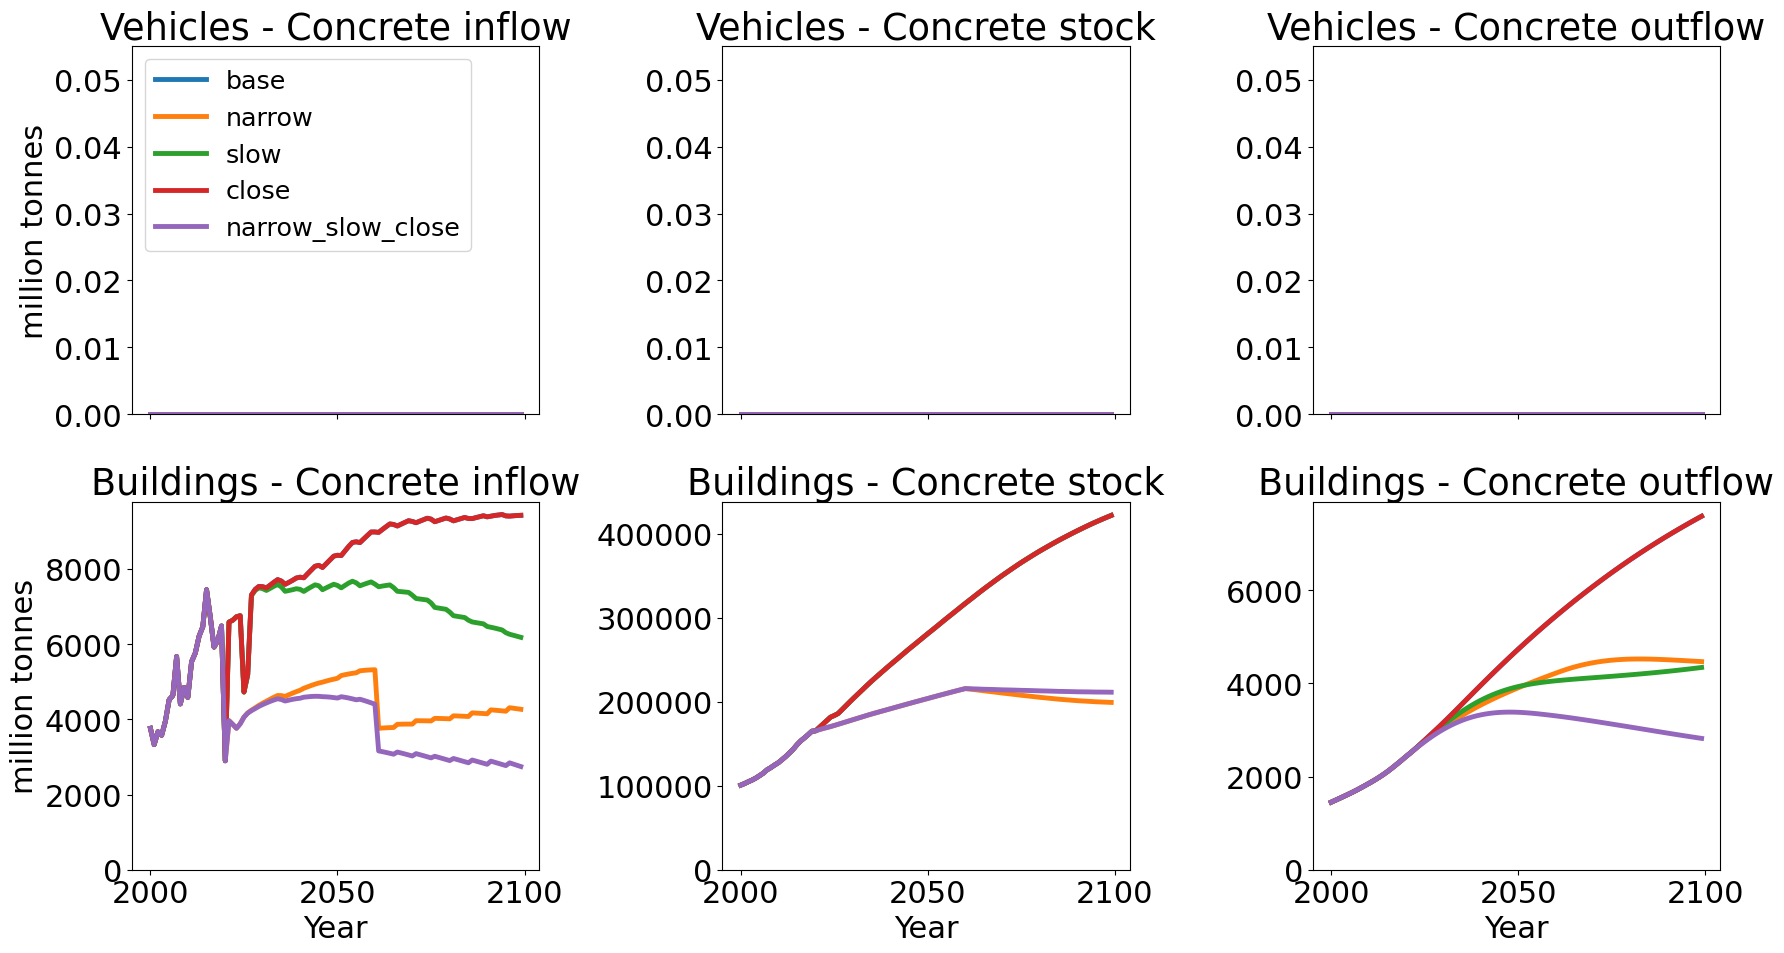

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
t0 = 2000
linewidth = 3.5 
alpha=1
material = "Concrete"
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()


colors = sns.color_palette("tab10")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# --- Vehicles - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(t0, 2100))
    time = inflow.coords["time"]
    axes[0].plot(time, inflow.sum("Region").sel(material=material).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[0].set_title(f"Vehicles - {material} inflow")
axes[0].set_ylabel("million tonnes")
axes[0].set_ylim(bottom=0)

# --- Vehicles - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][0].sel(Time=range(t0, 2100))
    Time = stock.coords["Time"]
    axes[1].plot(Time, stock.sum("Region").sel(material=material).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[1].set_title(f"Vehicles - {material} stock")
axes[1].set_ylim(bottom=0)

# --- Vehicles - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][0].to_array().sel(time=range(t0, 2100))
    time = outflow.coords["time"]
    axes[2].plot(time, outflow.sum("Region").sel(material=material).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[2].set_title(f"Vehicles - {material} outflow")
axes[2].set_ylim(bottom=0)

# --- Buildings - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][1].to_array().sel(time=range(t0, 2100))
    time = inflow.coords["time"]
    axes[3].plot(time, inflow.sum("Region").sel(material=material).sum("Type") / 1e3, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[3].set_title(f"Buildings - {material} inflow")
axes[3].set_xlabel("Year")
axes[3].set_ylabel("million tonnes")
axes[3].set_ylim(bottom=0)

# --- Buildings - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][1].sel(Time=range(t0, 2100))
    Time = stock.coords["Time"]
    axes[4].plot(Time, stock.sum("Region").sel(material=material).sum("Type") / 1e3, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[4].set_title(f"Buildings - {material} stock")
axes[4].set_xlabel("Year")
axes[4].set_ylim(bottom=0)

# --- Buildings - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][1].to_array().sel(time=range(t0, 2100))
    time = outflow.coords["time"]
    axes[5].plot(time, outflow.sum("Region").sel(material=material).sum("Type") / 1e3, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[5].set_title(f"Buildings - {material} outflow")
axes[5].set_xlabel("Year")
axes[5].set_ylim(bottom=0)

# Legend and layout
axes[0].legend(loc="upper left", fontsize='small')
plt.rcParams.update({'font.size': 22})


plt.tight_layout()
plt.show()


In [16]:
output["inflow_materials"][1]

TimeVariable(
  timeline=Timeline(start=1921, end=2100, stepsize=1),
  unit=count,
  dims=
	Dimension(label="Region", coords=[np.str_('1'), np.str_('2'), np.str_('3'),
	  np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'),
	  np.str_('9'), np.str_('10'), np.str_('11'), np.str_('12'),
	  np.str_('13'), np.str_('14'), np.str_('15'), np.str_('16'),
	  np.str_('17'), np.str_('18'), np.str_('19'), np.str_('20'),
	  np.str_('21'), np.str_('22'), np.str_('23'), np.str_('24'),
	  np.str_('25'), np.str_('26')])
        Dimension(label="Type",
	  coords=[np.str_('Appartment - Rural'), np.str_('Appartment - Urban'),
	  np.str_('Detached - Rural'), np.str_('Detached - Urban'), np.str_('High-
	  rise - Rural'), np.str_('High-rise - Urban'), np.str_('Semi-detached -
	  Rural'), np.str_('Semi-detached - Urban'), np.str_('Office'),
	  np.str_('Retail+'), np.str_('Hotels+'), np.str_('Govt+')])
	  Dimension(label="material", coords=['Aluminium', 'Brick', 'Cement',
	  'Concrete', 'Coppe

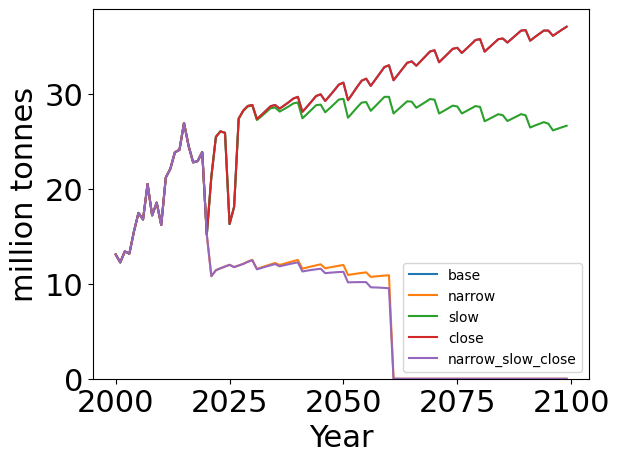

In [19]:
plt.xlabel("Year")
plt.ylabel("million tonnes")
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][1].to_array().sel(time=range(2000, 2100))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sel(Type ='Appartment - Urban')/1e3, label=scen_id)
plt.ylim(bottom = 0)
plt.legend(fontsize =10)
plt.show()

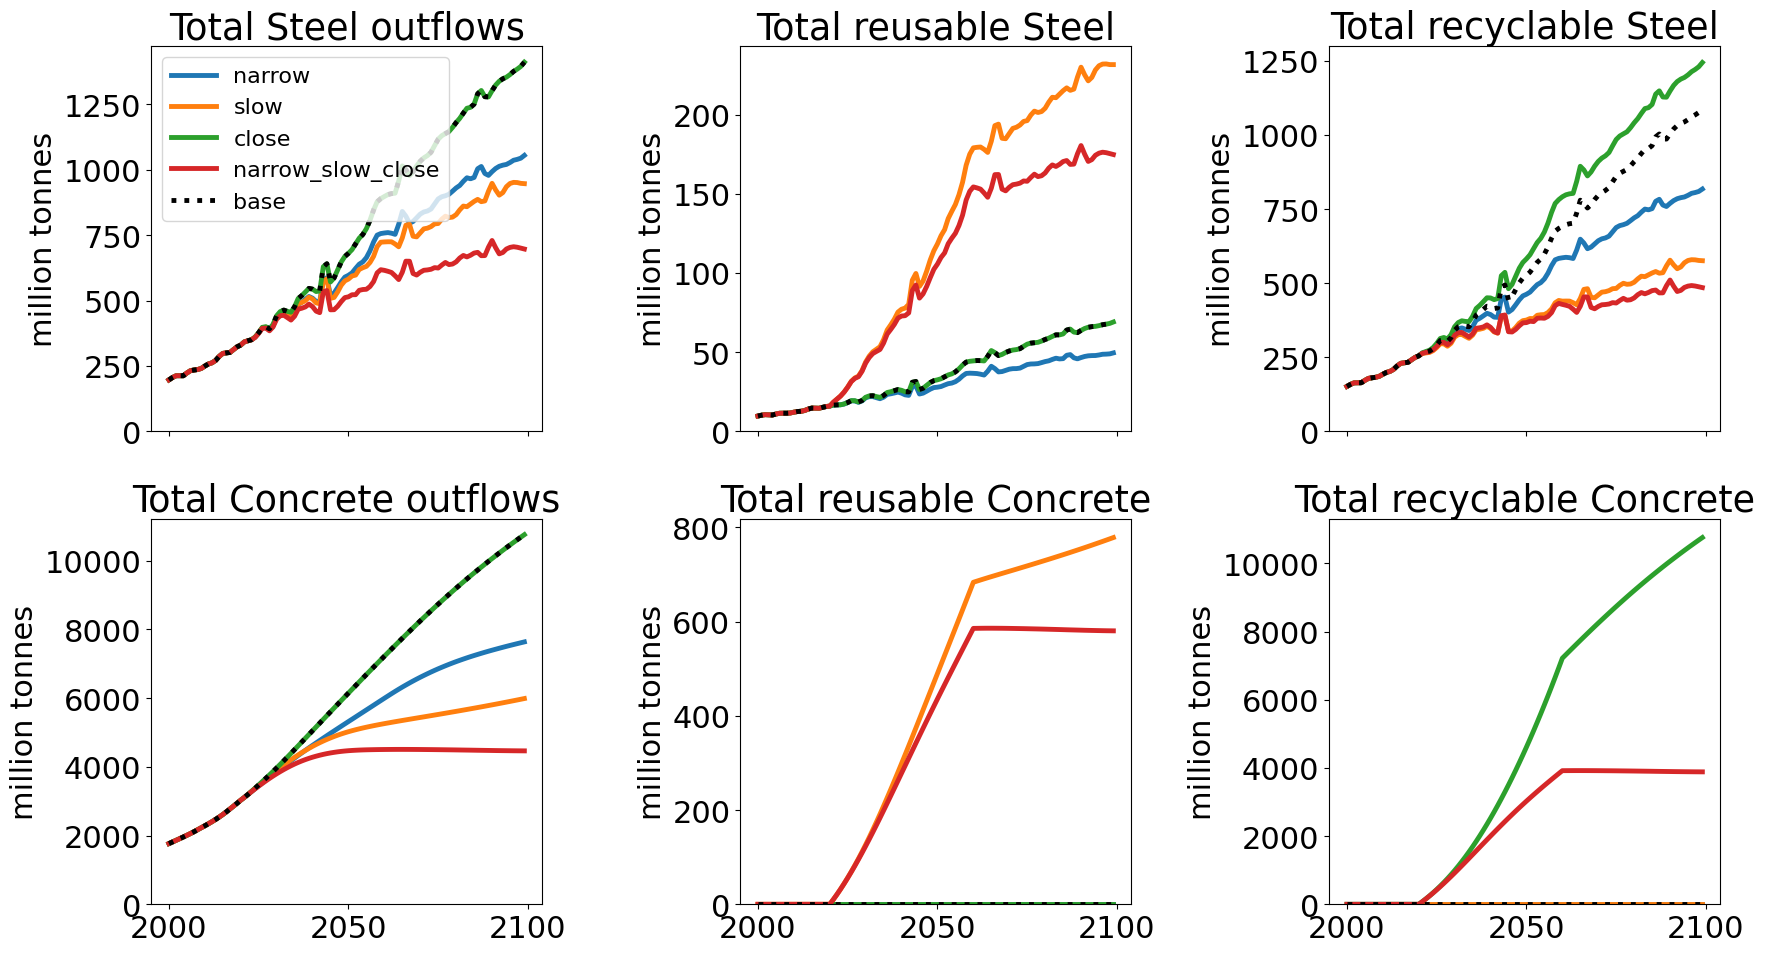

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

t0 = 2000
linewidth = 3.5
alpha = 1
material1 = "Steel"
material2 = "Concrete"

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

colors = sns.color_palette("tab10")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

def plot_scenarios(ax, variable, material, title):
    # First plot all scenarios except 'base'
    for scen_id, output in all_output.items():
        if scen_id.lower() != "base":
            inflow = output[variable].to_array().sel(time=range(t0, 2100))
            time = inflow.coords["time"]
            ax.plot(
                time,
                inflow.sum("Region").sel(material=material).sum("Type"),
                label=scen_id,
                linewidth=linewidth,
                alpha=alpha
            )

    # Then plot 'base' last, dotted line
    if "base" in [s.lower() for s in all_output.keys()]:
        for scen_id, output in all_output.items():
            if scen_id.lower() == "base":
                inflow = output[variable].to_array().sel(time=range(t0, 2100))
                time = inflow.coords["time"]
                ax.plot(
                    time,
                    inflow.sum("Region").sel(material=material).sum("Type"),
                    label=scen_id,
                    linewidth=linewidth,
                    alpha=alpha,
                    linestyle="dotted",
                    color="black"  # force black for visibility
                )

    ax.set_title(title)
    ax.set_ylabel("million tonnes")
    ax.set_ylim(bottom=0)

# Plot for each subplot
plot_scenarios(axes[0], "sum_outflow", material1, f"Total {material1} outflows")
plot_scenarios(axes[1], "reusable_materials", material1, f"Total reusable {material1}")
plot_scenarios(axes[2], "recyclable_materials", material1, f"Total recyclable {material1}")
plot_scenarios(axes[3], "sum_outflow", material2, f"Total {material2} outflows")
plot_scenarios(axes[4], "reusable_materials", material2, f"Total reusable {material2}")
plot_scenarios(axes[5], "recyclable_materials", material2, f"Total recyclable {material2}")

# Legend and layout
axes[0].legend(loc="upper left", fontsize=16)
plt.rcParams.update({'font.size': 22})

plt.tight_layout()
plt.show()


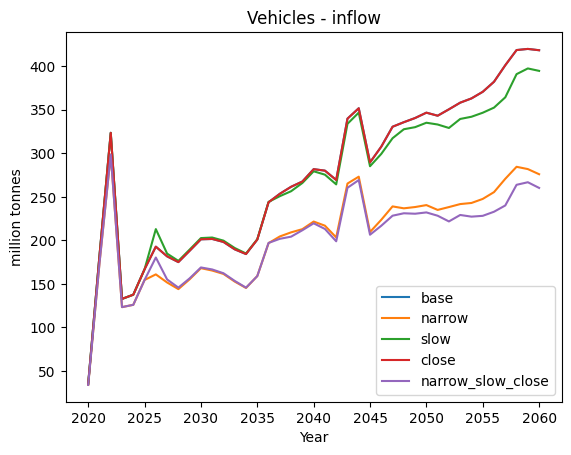

In [25]:
from matplotlib import pyplot as plt
plt.title("Vehicles - inflow")
plt.xlabel("Year")
plt.ylabel("million tonnes")
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type")/1e9, label=scen_id)
plt.legend()
plt.show()

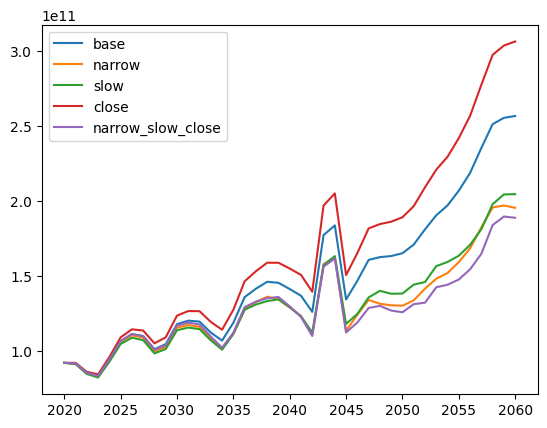

In [ ]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["recyclable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()
plt.show()

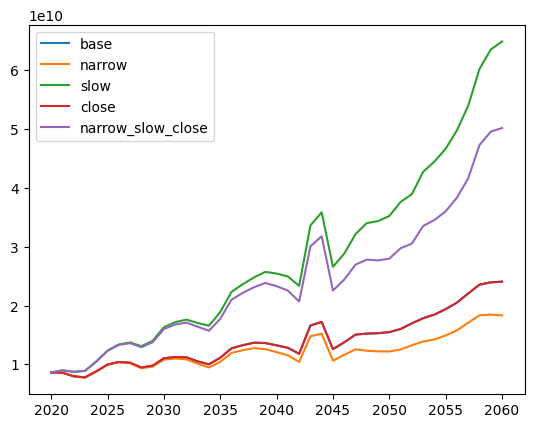

In [21]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["reusable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()